# Dimension-wise Class Activation Map (dCAM)



In [40]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

/tmp/ipykernel_497859/82325636.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from random import randint
import os
import sys
from torch.utils import data
import torch
from torch.autograd import Variable

In [42]:
sys.path.insert(0, '../src/models')
from CNN_models import ConvNet2D, ModelCNN, TSDataset
sys.path.insert(0, '../src/explanation')
from DCAM import DCAM

## Functions for synthetic dataset construction
### Parameters

In [43]:
# Number of instance of Class 1 to concatenate on each dimension
nb_seq = 5

### Functions

In [44]:
def gen_cube(instance):
    """
        Generate a cube structure from a given multivariate instance.

        Parameters
        ----------
        instance : list
            List of sequences (e.g., multivariate time series), where each element corresponds to a channel.

        Returns
        -------
        list
            A cube structure (list of lists) where each sublist is a cyclic permutation of the input instance.
        """
    result = []
    for i in range(len(instance)):
        result.append([instance[(i+j)%len(instance)] for j in range(len(instance))])
    return result

def get_md5sum_arr(*arrs):
    """
    Compute the MD5 checksum for each input NumPy array.
    Parameters
    ----------
    *arrs : array-like
        One or more NumPy arrays for which to compute the MD5 checksum.
    Returns
    -------
    list of str
        A list containing the hexadecimal MD5 checksum string for each input array.
    Notes
    -----
    The function ensures that each array is stored in contiguous memory before computing the checksum,
    to guarantee consistent results regardless of the original memory layout.
    """
    import hashlib
    out = []
    for arr in arrs:
        arr_c = np.ascontiguousarray(arr)  # ensure memory layout consistency
        out.append(hashlib.md5(arr_c.tobytes()).hexdigest())
    return out

### Loading our Synthetic Dataset

In [45]:
# Load scintillation signals stored as a pickle tuple (class_weak, class_strong)
data_path = Path('scint_signals4.pkl')
with data_path.open('rb') as f:
    class_weak, class_strong = pickle.load(f)

# downsample signals to reduce computational cost
downsample_factor = 2
class_weak = [[10*np.log10(np.square(sig[::downsample_factor])) for sig in instance] for instance in class_weak]
class_strong = [[10*np.log10(np.square(sig[::downsample_factor])) for sig in instance] for instance in class_strong]

# dataset metadata
n_class = 2
n_instance = min(len(class_weak), len(class_strong))
n_chan = len(class_weak[0])
n_sample = len(class_weak[0][0])
class_weak = class_weak[:n_instance]
class_strong = class_strong[:n_instance]

print(f'Loaded {n_instance} scintillation instances per class from {data_path.name}.')
print(f'Each sample contains {n_chan} channels with {n_sample} samples.')
print(f'Total dataset size: {2 * n_instance} instances.')

Loaded 65 scintillation instances per class from scint_signals4.pkl.
Each sample contains 25 channels with 751 samples.
Total dataset size: 130 instances.


### Class Strong Visualization for 7th instance

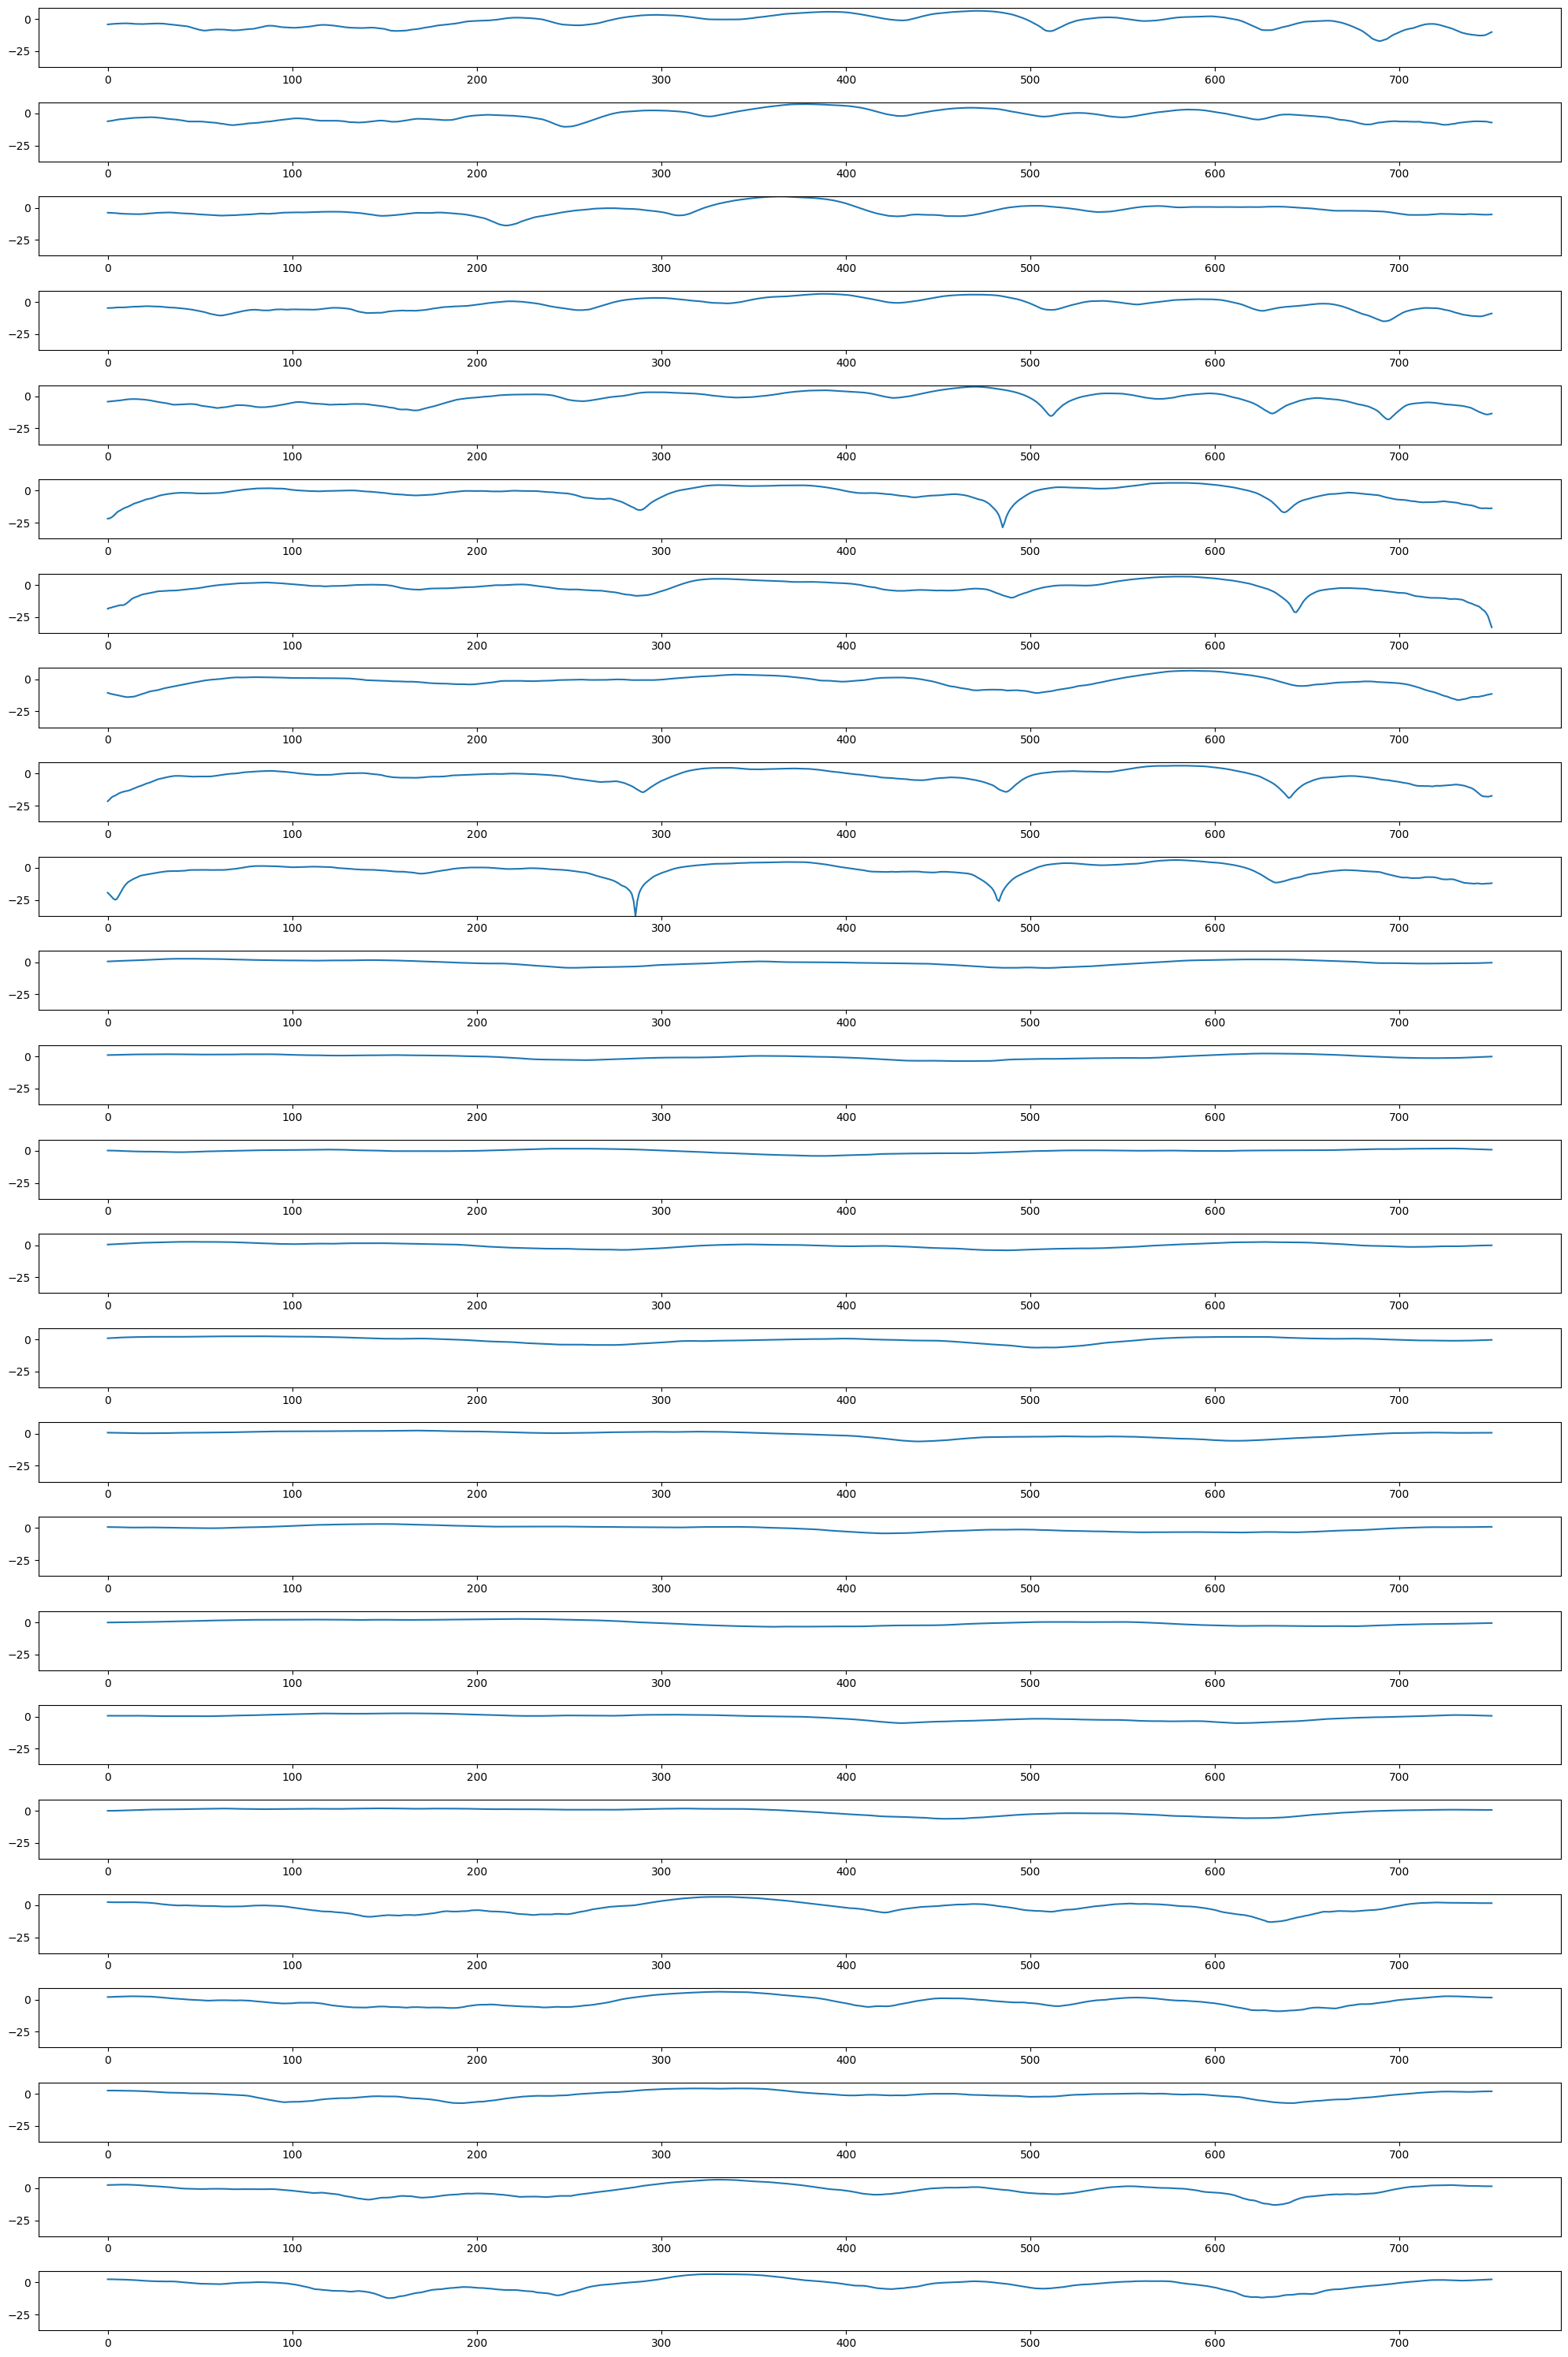

In [46]:
analyzed_instance = 7
global_ymin = min([min(sig) for sig in class_strong[analyzed_instance]])
global_ymax = max([max(sig) for sig in class_strong[analyzed_instance]])
plt.figure(figsize=(20,30))
for i in range(len(class_strong[1])):
    plt.subplot(len(class_strong[1]),1,1+i)
    plt.plot(class_strong[analyzed_instance][i])
    plt.ylim(global_ymin, global_ymax)

plt.tight_layout(h_pad=1.5)

### Class Weak Visualization for 7th instance (same limits)

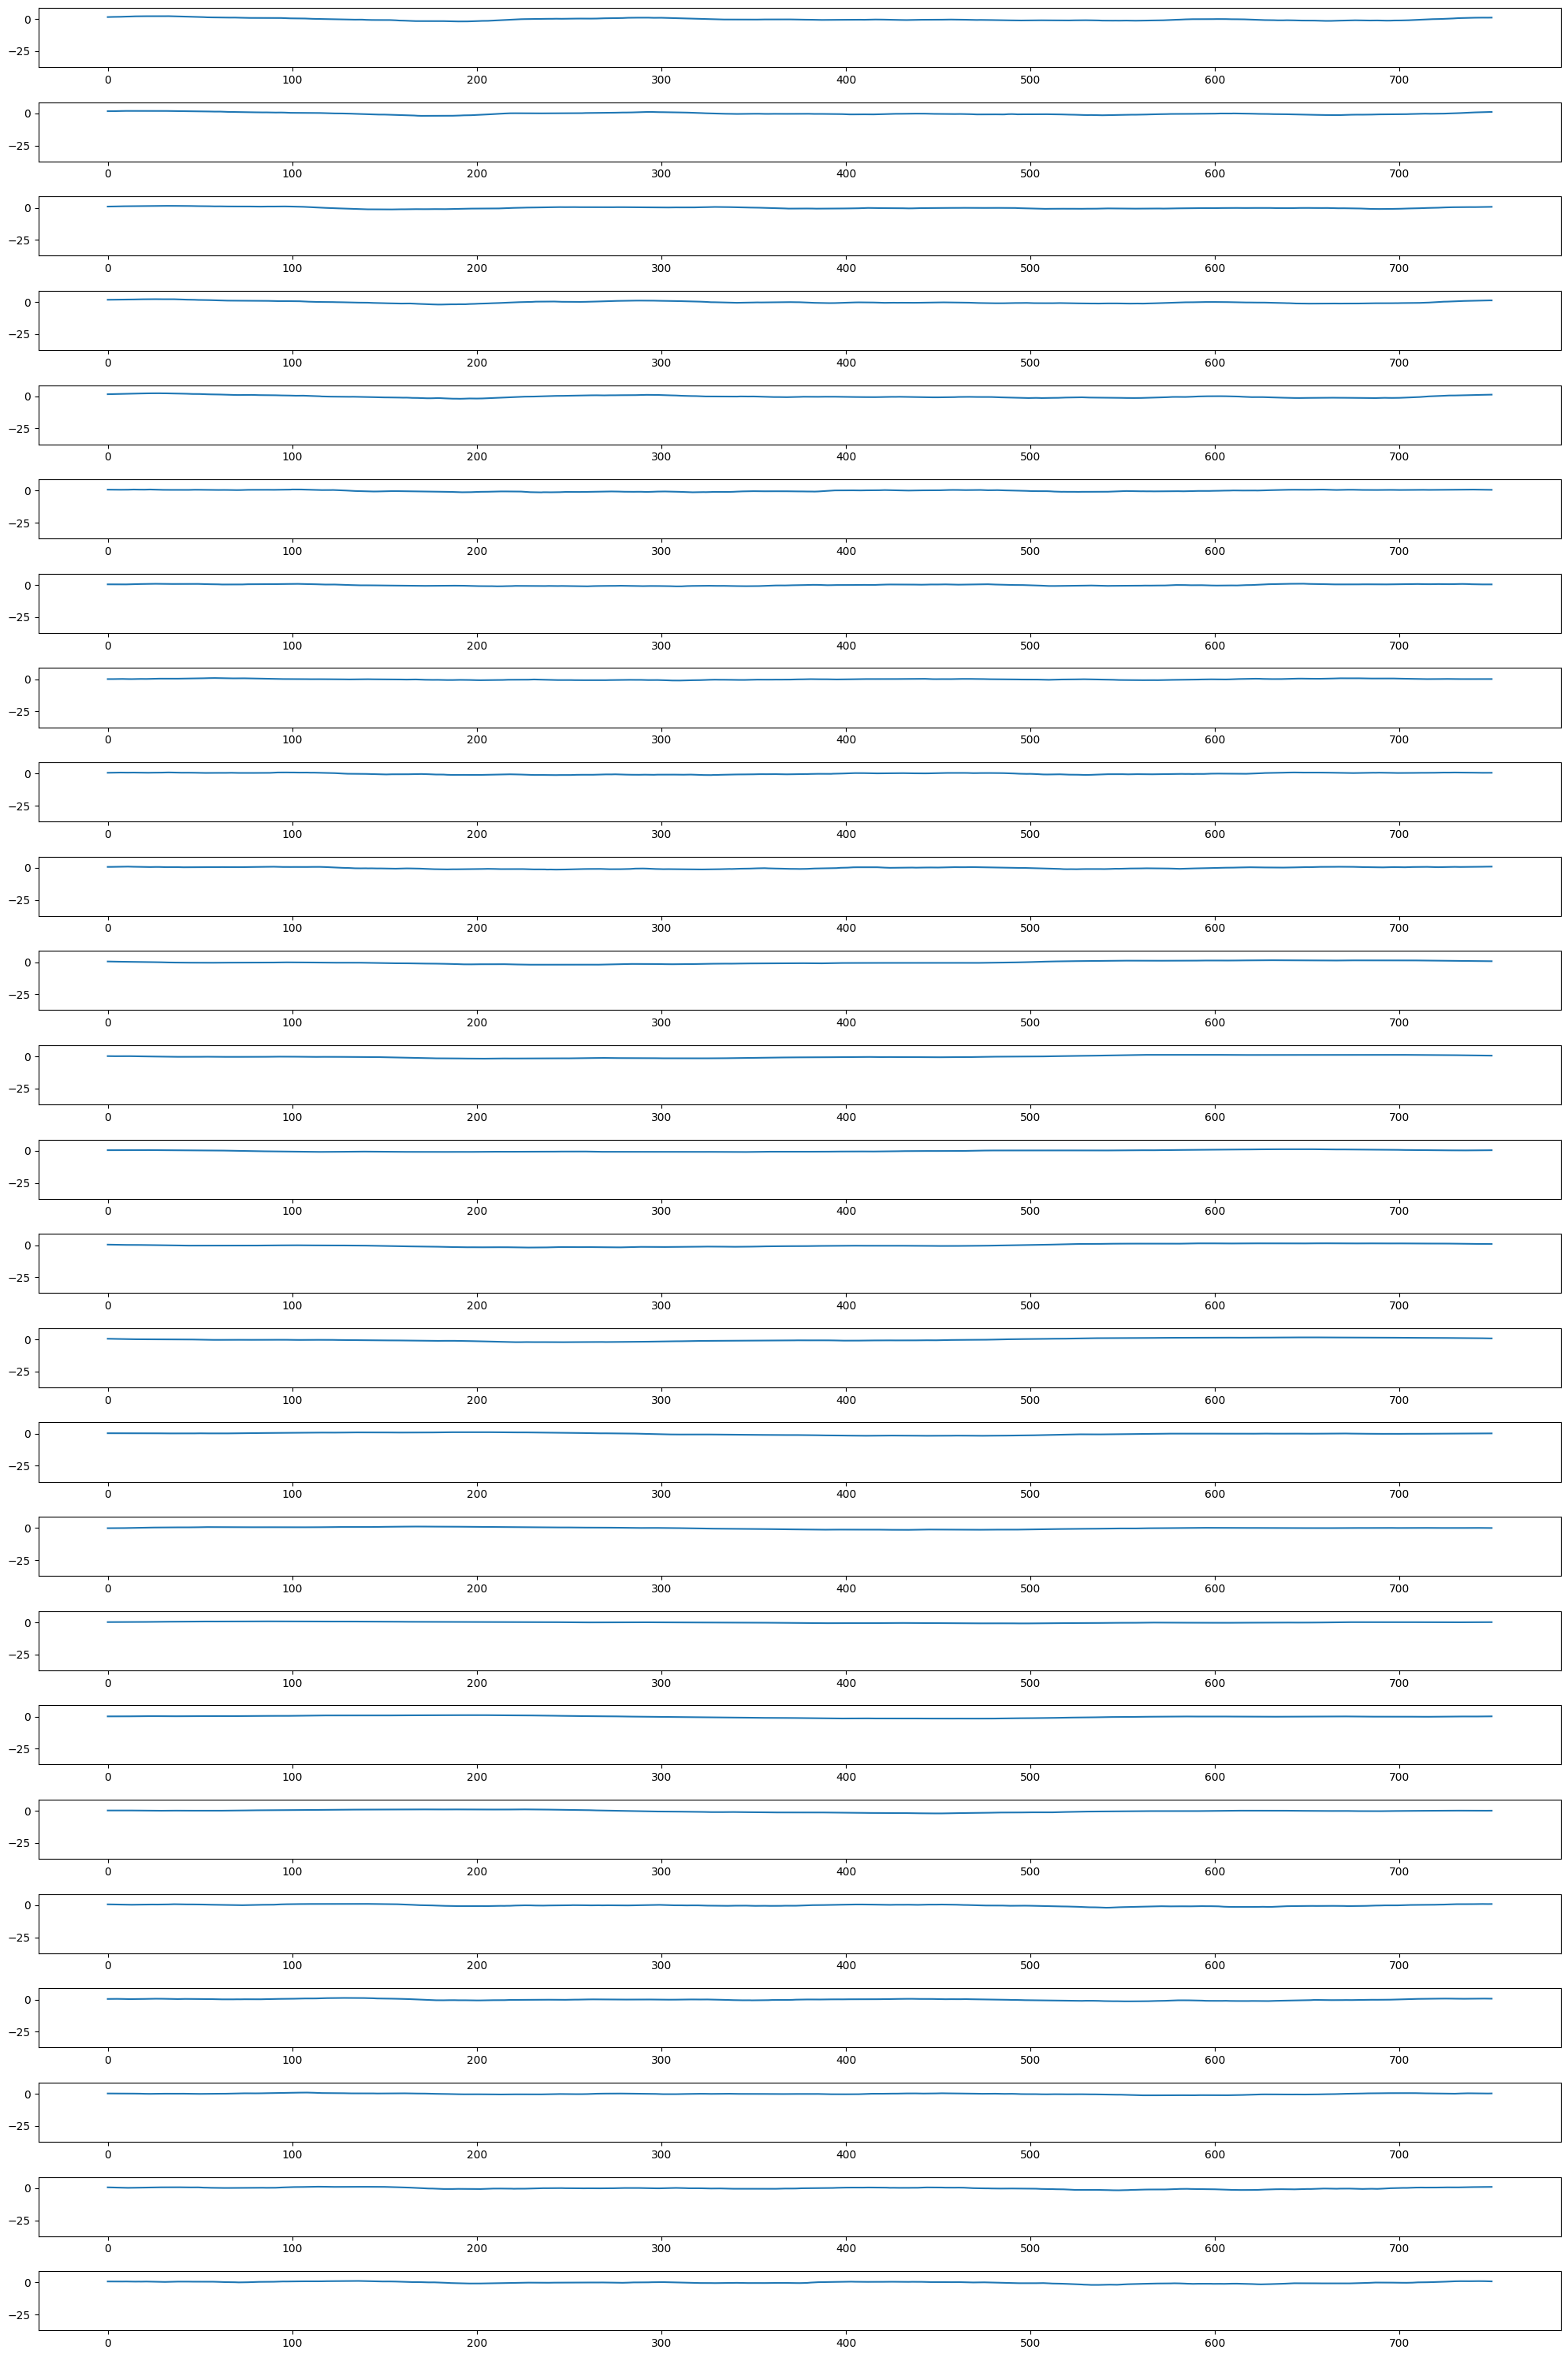

In [47]:
analyzed_instance = 7
plt.figure(figsize=(20,30))
for i in range(len(class_weak[1])):
    plt.subplot(len(class_weak[1]),1,1+i)
    plt.plot(class_weak[analyzed_instance][i])
    plt.ylim(global_ymin, global_ymax)

plt.tight_layout(h_pad=1.5)

### Training Parameter

In [48]:
def require_cuda():
    # Do not change CUDA_VISIBLE_DEVICES after kernel start.
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA not available in this process. Check driver, nvidia-smi, and CUDA_VISIBLE_DEVICES.")
    try:
        _ = torch.empty(1, device="cuda")
        torch.cuda.synchronize()
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")
    except Exception as e:
        raise RuntimeError(f"CUDA detected but unusable: {e}. Likely stale processes or driver issue.")

device = require_cuda()
train_test_r = 0.75
batch_size = 32
print(f"Using device: {device}")


Using GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Using device: cuda


### Generate pyTorch-like datasets 

In [49]:
# for md5sum in get_md5sum_arr(class_weak, class_strong):
#     print(f"MD5 checksum: {md5sum}")

train_size = int(n_instance * train_test_r)
test_size = n_instance - train_size

label_trn = np.array([0] * train_size + [1] * train_size)
label_tst = np.array([0] * test_size + [1] * test_size)

all_class_trn = class_weak[:train_size] + class_strong[:train_size]
all_class_tst = class_weak[train_size:train_size + test_size] + class_strong[train_size:train_size + test_size]

all_class_trn = np.array([gen_cube(acl) for acl in all_class_trn])
all_class_tst = np.array([gen_cube(acl) for acl in all_class_tst])

for md5sum in get_md5sum_arr(all_class_trn, label_trn, all_class_tst, label_tst):
        print(f"MD5 checksum: {md5sum}")

x = all_class_trn
dataset_mat = TSDataset(x,label_trn)
dataloader_cl1_trn = data.DataLoader(dataset_mat, batch_size=batch_size, shuffle=True)

x = all_class_tst
dataset_mat_test = TSDataset(x,label_tst)
dataloader_cl1_tst = data.DataLoader(dataset_mat_test, batch_size=1, shuffle=True)

MD5 checksum: 6940f0e05ba9346227427584979897d7
MD5 checksum: 88746164447783735979a003051580b5
MD5 checksum: 757f89722b7fd20db4b9a190dac1f928
MD5 checksum: 809e657f54a6bdd1f819e68222964421


In [50]:
print(f"all_class_trn shape: {all_class_trn.shape} (samples: {all_class_trn.shape[0]}, channel: {all_class_trn.shape[1]}, cube channel: {all_class_trn.shape[2]}, length: {all_class_trn.shape[3]})")
print(f"all_class_tst shape: {all_class_tst.shape} (samples: {all_class_tst.shape[0]}, channel: {all_class_tst.shape[1]}, cube channel: {all_class_tst.shape[2]}, length: {all_class_tst.shape[3]})")

all_class_trn shape: (96, 25, 25, 751) (samples: 96, channel: 25, cube channel: 25, length: 751)
all_class_tst shape: (34, 25, 25, 751) (samples: 34, channel: 25, cube channel: 25, length: 751)


In [51]:
# Check the type of the dataset_mat object
print("Type of `dataset_mat`:", type(dataset_mat))
# Get a single instance (x1: data, y1: label) from the dataset
x1, y1 = next(iter(dataset_mat))
print("A single iteration over `dataset_mat` is a (D,D,n_sample) train instance:")
print("x1 shape:", x1.shape)  # Should be (8, 8, 342)
print("y1 label:", y1)

print("\nType of `dataloader_cl1`:", type(dataloader_cl1_trn))
# Get a mini-batch (xb: batch data, yb: batch labels) from the dataloader
xb, yb = next(iter(dataloader_cl1_trn))
print("A single iteration over `dataloader_cl1_trn` is a (batch_size, 8, 8, 342) mini-batch instance:")
print("xb shape:", xb.shape)  # Should be (batch_size, 8, 8, 342)
print("yb shape:", yb.shape)  # Should be (batch_size,)

Type of `dataset_mat`: <class 'CNN_models.TSDataset'>
A single iteration over `dataset_mat` is a (D,D,n_sample) train instance:
x1 shape: (25, 25, 751)
y1 label: 0

Type of `dataloader_cl1`: <class 'torch.utils.data.dataloader.DataLoader'>
A single iteration over `dataloader_cl1_trn` is a (batch_size, 8, 8, 342) mini-batch instance:
xb shape: torch.Size([32, 25, 25, 751])
yb shape: torch.Size([32])


# Training the model

Note that the usage of Batchnorm layer is not appropriate to all use cases. By expirience, this layer cause an instablility and a lower convergence is some of the use cases tested. It seems that this layer make some pertubation fail to be classified.

### Training the model

In [52]:
from torchsummary import summary

#dCNN
modelarch = ConvNet2D(n_sample,n_chan,n_chan,n_class).to(device)

model = ModelCNN(modelarch,device)

summary(model.model.to(device),input_size=(n_chan,n_chan,n_sample), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 128, 25, 751]           9,728
       BatchNorm2d-2         [-1, 128, 25, 751]             256
              ReLU-3         [-1, 128, 25, 751]               0
            Conv2d-4         [-1, 128, 25, 751]          49,280
       BatchNorm2d-5         [-1, 128, 25, 751]             256
              ReLU-6         [-1, 128, 25, 751]               0
            Conv2d-7         [-1, 256, 25, 751]          98,560
       BatchNorm2d-8         [-1, 256, 25, 751]             512
              ReLU-9         [-1, 256, 25, 751]               0
           Conv2d-10         [-1, 256, 25, 751]         196,864
      BatchNorm2d-11         [-1, 256, 25, 751]             512
             ReLU-12         [-1, 256, 25, 751]               0
           Conv2d-13         [-1, 256, 25, 751]         196,864
             ReLU-14         [-1, 256, 

In [53]:
dataloader_cl1_tst.batch_size

1

In [55]:
model.train(num_epochs=70,dataloader_cl1=dataloader_cl1_trn,dataloader_cl1_test=dataloader_cl1_tst)

Epoch [1/70], Loss Train: 0.6854,Loss Test: 0.6920, Accuracy Train: 50.00%, Accuracy Test: 50.00%
Epoch [11/70], Loss Train: 0.4692,Loss Test: 0.4895, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [21/70], Loss Train: 0.3285,Loss Test: 0.3099, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [31/70], Loss Train: 0.2295,Loss Test: 0.2130, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [41/70], Loss Train: 0.1565,Loss Test: 0.1468, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [51/70], Loss Train: 0.1234,Loss Test: 0.1033, Accuracy Train: 100.00%, Accuracy Test: 100.00%
Epoch [61/70], Loss Train: 0.0907,Loss Test: 0.0753, Accuracy Train: 100.00%, Accuracy Test: 100.00%


### Train and test loss (Binary Cross Entropy) versus Epoch  

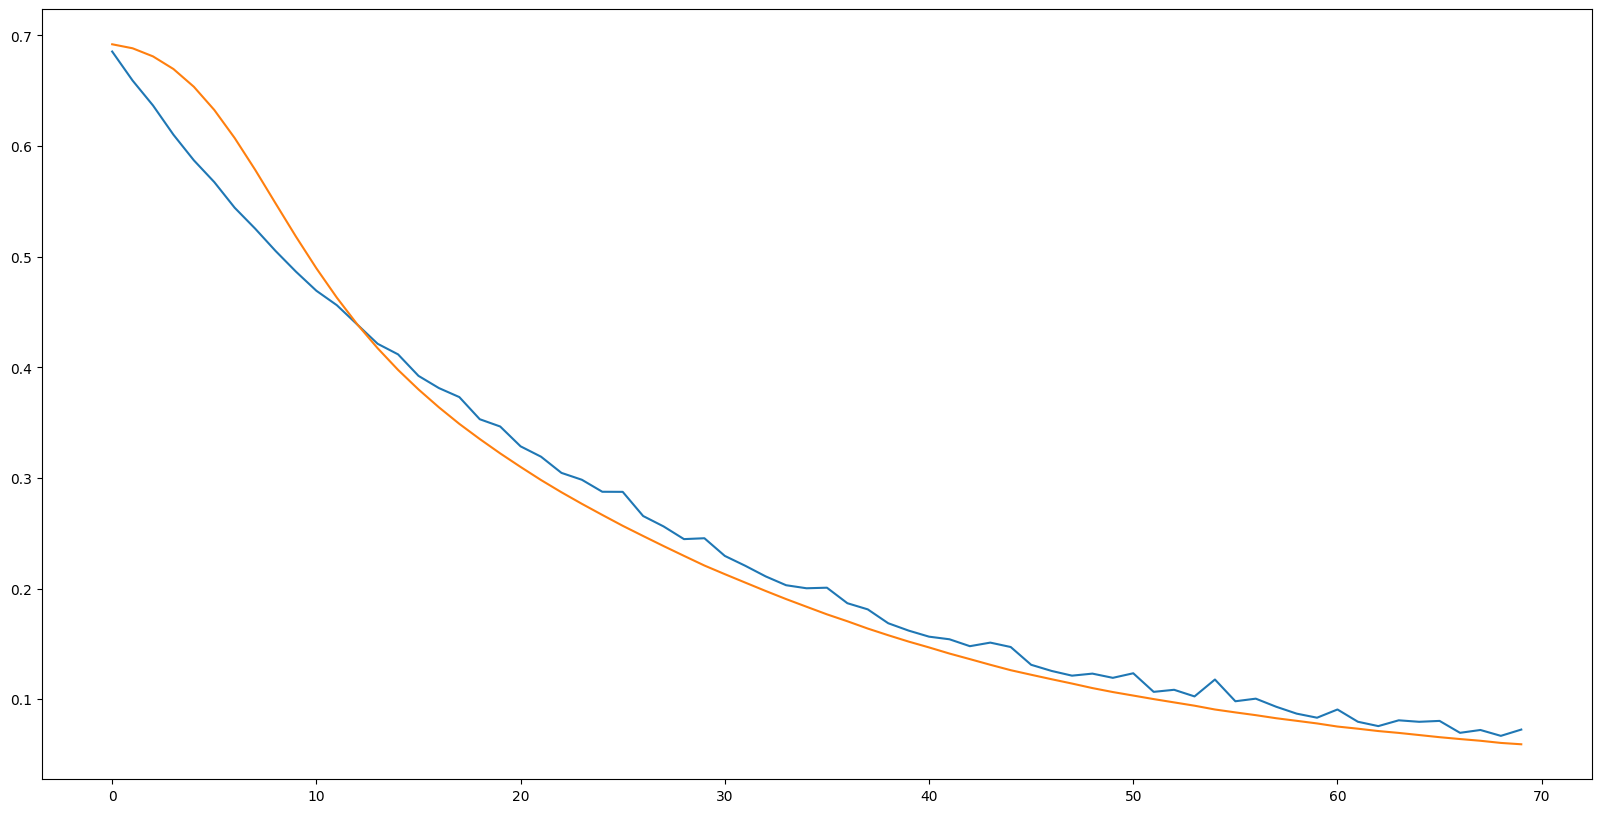

In [56]:
plt.figure(figsize=(20,10))
plt.plot(model.loss_train_history)
plt.plot(model.loss_test_history)

# d-CAM Class Activation Map


In [57]:
model = torch.load("model", map_location=device, weights_only=False).to(device)
model = model.eval()

instance_idx = 3
instance = np.array(class_strong[instance_idx])
label_instance = 1

instance_to_try = Variable(
    torch.tensor(
        instance.reshape(
            (1,1,n_chan,n_sample))).float().to(device),
    requires_grad=True)


# dCNN
last_conv_layer = model._modules['layer3']
fc_layer_name = model._modules['fc1']

# dResNet
#last_conv_layer = model.model._modules['layers'][2]
#fc_layer_name = model.model._modules['final']

#InceptionTime
#last_conv_layer = model.model._modules['blocks'][2]
#fc_layer_name = model.model._modules['linear']



DCAM_m = DCAM(model,device,last_conv_layer=last_conv_layer,fc_layer_name=fc_layer_name)
dcam, permutation_success = DCAM_m.run(
    instance=instance,
    nb_permutation=200,
    label_instance=label_instance)

  0%|          | 0/200 [00:00<?, ?it/s]/home/tapyu/git/dCAM/examples/../src/explanation/DCAM.py:113: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  pred_probabilities = F.softmax(prediction).data.squeeze()
100%|██████████| 200/200 [00:11<00:00, 18.05it/s]


# Plot for strong

/tmp/ipykernel_497859/2570497686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_497859/2570497686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_497859/2570497686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_497859/2570497686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"Dim {i}"])
/tmp/ipykernel_497859/2570497686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels

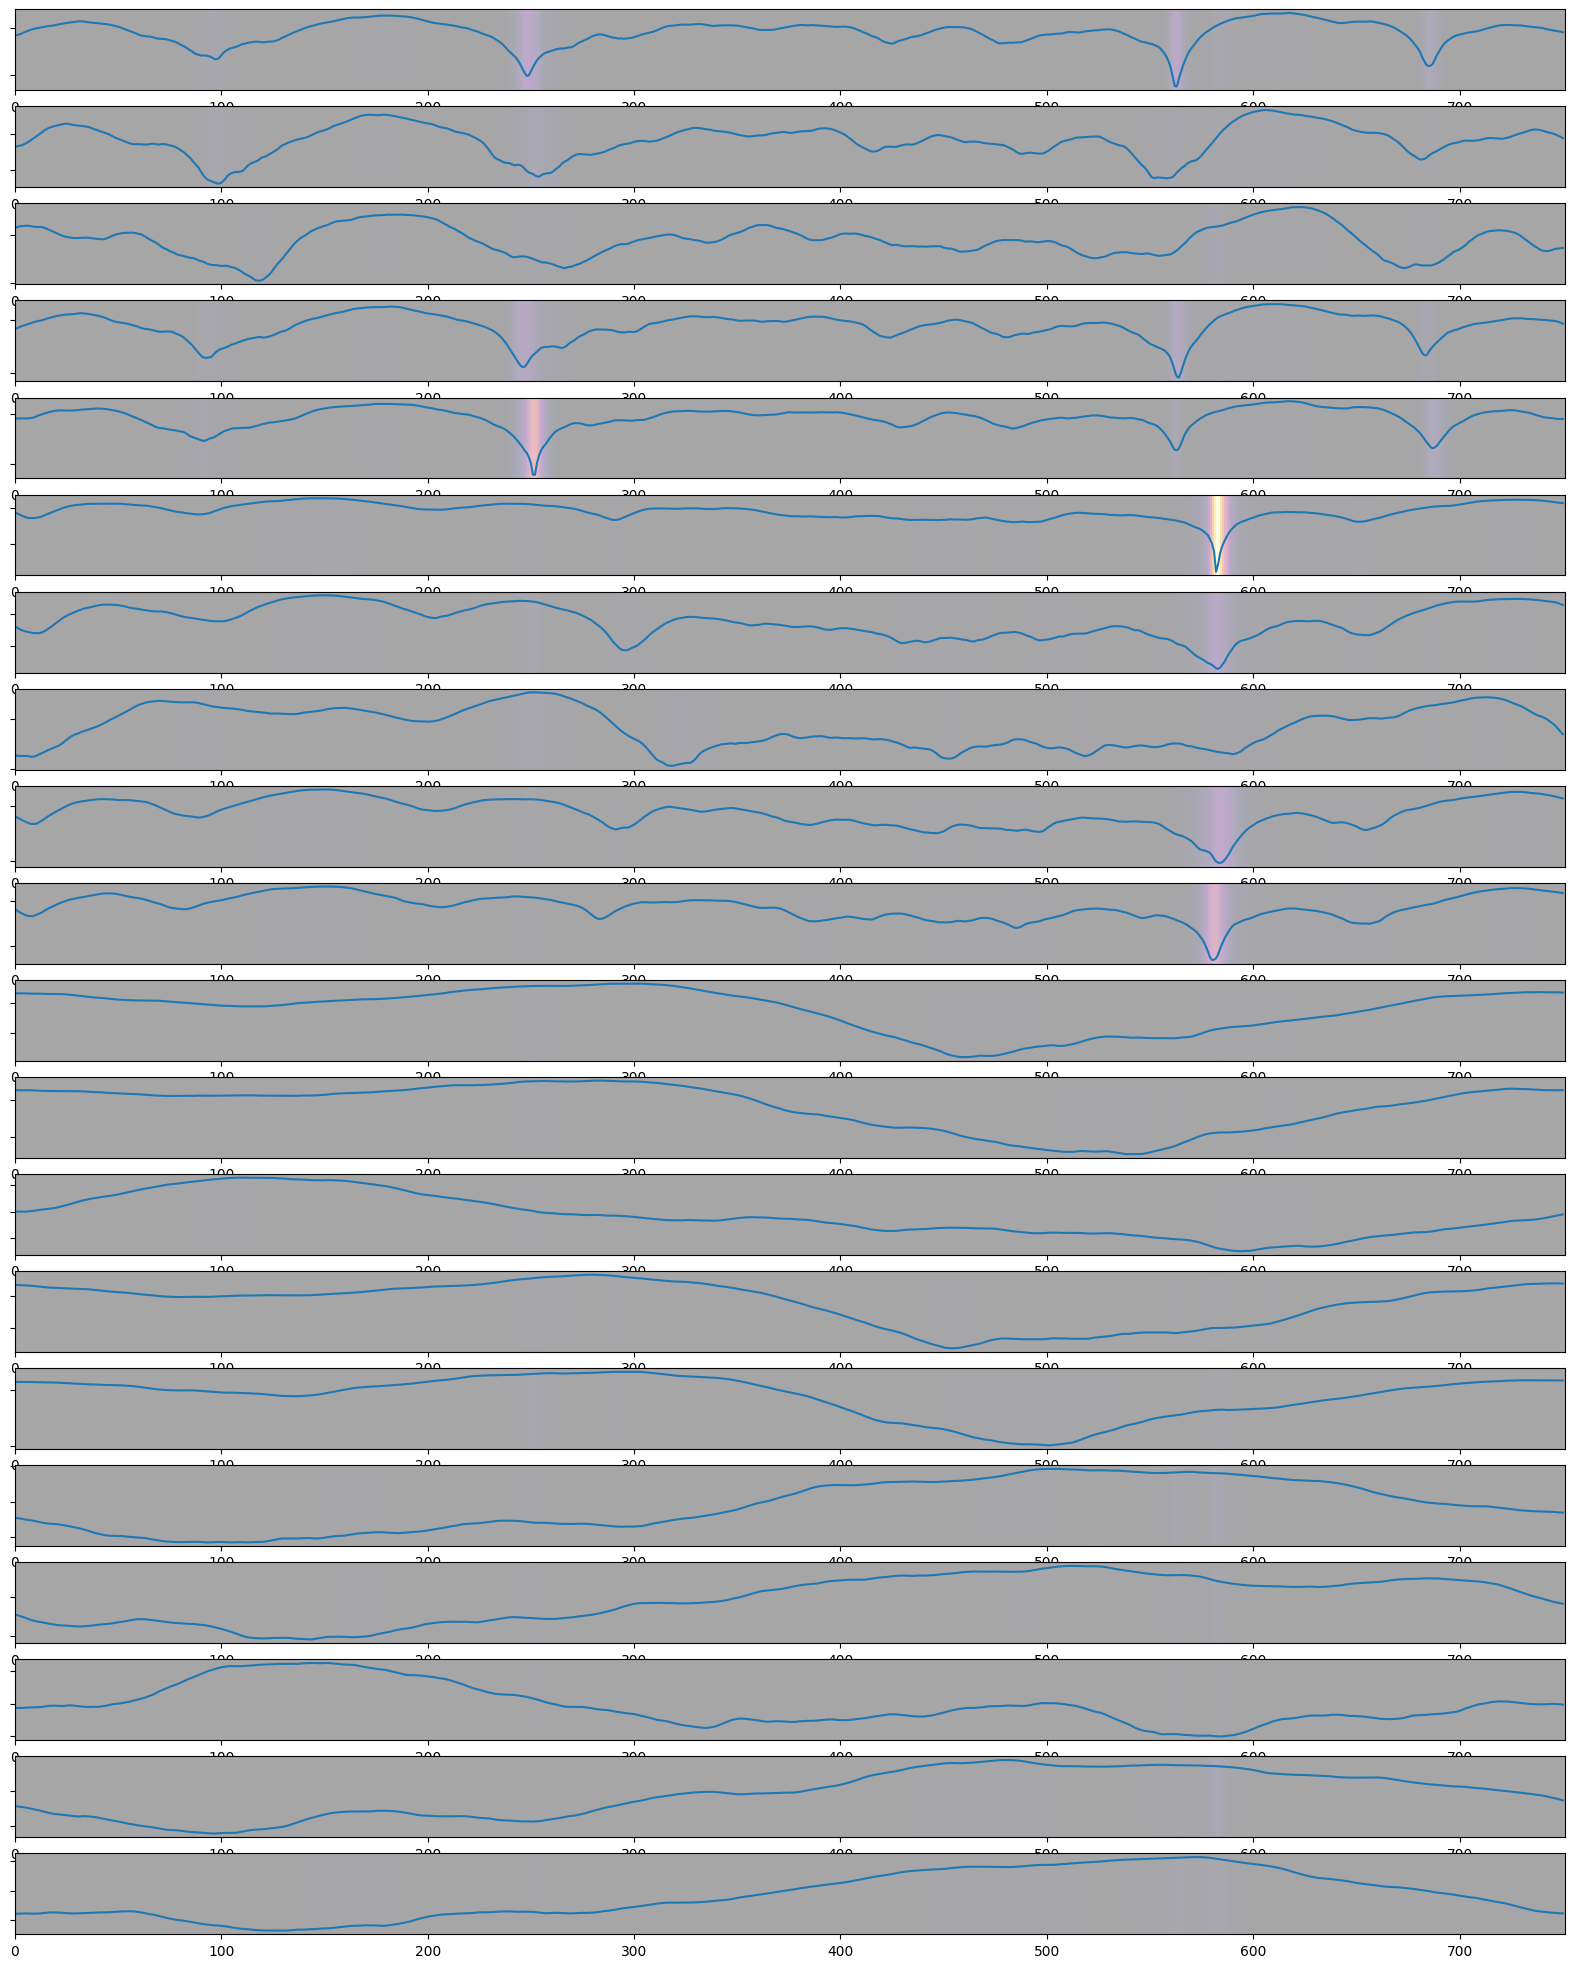

In [58]:
K = 20
dcam_min = np.min(dcam)
dcam_max = np.max(dcam)
dcam_range = dcam_max - dcam_min

dcam_norm = (dcam - dcam_min) / dcam_range
vmin, vmax = float(dcam_norm.min()), float(dcam_norm.max())

plt.figure(figsize=(20, 25))
for i in range(K):
    ax = plt.subplot(K, 1, i + 1)
    ax.plot(instance[i], color="tab:blue")
    ax.set_xlim(0, len(instance[i]))
    ax.set_yticklabels([f"Dim {i}"])

    ymin, ymax = ax.get_ylim()
    ax.imshow(
        dcam_norm[i][np.newaxis, :],
        extent=[0, len(dcam[i]), ymin, ymax],
        aspect="auto",
        cmap="inferno",
        alpha=0.35,
        vmin=vmin, vmax=vmax, # enforce global scaling
        interpolation="none",
    )
    ax.set_ylim(ymin, ymax)
